# 08 · Calibration and the money threshold (Step 10)

**Goal:** make the final model's probabilities trustworthy, then turn them into an approve/decline
rule based on money instead of an arbitrary cut-off.

- **A. Calibration:** compare no calibration, Platt scaling (sigmoid) and isotonic regression,
  overall and per gender.
- **B. Money threshold:** approve when p < m / (m + LGD) (section 10.7 of the plan), and check it
  against the threshold that actually made the most money on the validation split.
- **C. Sensitivity:** m and LGD are assumptions, so show how the threshold and approval rate move.

**Data rules:** everything here uses the **validation split** only. The conformal split stays
untouched for Step 11 and the test split stays locked until Step 15. The final model is not
retrained; it is only wrapped by a calibrator.

**Stretch goal (Bayesian logistic regression):** already done in Step 8 (notebook 07: Laplace
approximation, per-applicant uncertainty), so it is not repeated here.

**Time:** about 2 minutes.

**Saved results:**

- `reports/results_step10_calibration.csv`, `reports/results_step10_thresholds.csv`
- `reports/figures/fig20_reliability.png`, `fig21_profit_vs_threshold.png`, `fig22_threshold_sensitivity.png`
- `models/calibrated_final.joblib` and `models/decision.json` (used by Steps 11 and 16)

In [1]:
%load_ext autoreload
%autoreload 2

import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import StratifiedKFold, cross_val_predict

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.decision.threshold import break_even_threshold, realised_profit
from creditrisk.evaluation.metrics import evaluate, evaluate_at_threshold, expected_calibration_error
from creditrisk.features.build import load_features
from creditrisk.models.data import get_xy
from creditrisk.models.final import MODEL_DIR, load_final_model

SEED = set_seed()
FIG = get_path("figures")
REPORTS = PROJECT_ROOT / "reports"
facts = {}

model, details = load_final_model()
features = load_features()
splits = load_splits()
X_all, y, _, ids = get_xy(features, splits, "valid", include_sensitive=True)
gender = X_all["APP_CODE_GENDER"].astype(str).to_numpy()  # for the per-gender checks only
amount = X_all["APP_AMT_CREDIT"].to_numpy(dtype=float)   # loan size A in the profit formula
X = X_all[details["features"]]                            # the exact columns the model expects
p_raw = model.predict_proba(X)[:, 1]
print(f"validation split: {len(y):,} applicants, default rate {y.mean():.2%}, "
      f"model trained {details['saved_on']} ({details['chosen']})")
print("gender counts:", dict(zip(*np.unique(gender, return_counts=True))))

validation split: 30,751 applicants, default rate 8.07%, model trained 2026-10-09 (tuned)
gender counts: {'F': np.int64(20314), 'M': np.int64(10437)}


## A. Calibration

A calibrator maps the model's score to a probability: **Platt** fits a sigmoid (2 numbers),
**isotonic** fits any increasing step function (flexible, so it can overfit).

**Honest comparison:** a calibrator scored on the same rows it was fitted on looks better than it
is. So each applicant's calibrated probability comes from a calibrator fitted on the *other* 80% of
the validation split (5-fold cross-fitting). The chosen method is then refitted on the whole
validation split and saved.

In [2]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
probs = {"none": p_raw}
for method in ("sigmoid", "isotonic"):
    calibrator = CalibratedClassifierCV(FrozenEstimator(model), method=method)
    probs[method] = cross_val_predict(calibrator, X, y, cv=cv, method="predict_proba")[:, 1]

rows = {}
for name, p in probs.items():
    m = evaluate(y, p)
    rows[name] = {"ROC-AUC": m["roc_auc"], "Brier": m["brier"], "log loss": m["log_loss"],
                  "ECE": m["ece"],
                  "ECE (equal-size bins)": expected_calibration_error(y, p, strategy="quantile"),
                  "avg predicted p": p.mean()}
calibration = pd.DataFrame(rows).T.round(5)
calibration["actual default rate"] = round(float(y.mean()), 5)
display(calibration)
calibration.to_csv(REPORTS / "results_step10_calibration.csv")

# a paired bootstrap on the Brier score: is the better calibrator really better than none?
rng = np.random.default_rng(SEED)
best = calibration.drop("none")["Brier"].idxmin()
sq = {k: (p - y) ** 2 for k, p in probs.items()}
diffs = [np.mean(sq[best][i] - sq["none"][i])
         for i in (rng.integers(0, len(y), len(y)) for _ in range(1000))]
low, high = np.percentile(diffs, [2.5, 97.5])
print(f"better calibrator: {best}; Brier {best} - none = {np.mean(sq[best] - sq['none']):+.6f} "
      f"(95% CI {low:+.6f} to {high:+.6f})")
facts["calibration"] = calibration[["Brier", "ECE", "avg predicted p"]].to_dict("index")
facts["best_brier"] = (best, round(float(low), 6), round(float(high), 6))

,ROC-AUC,Brier,log loss,ECE,ECE (equal-size bins),avg predicted p,actual default rate
none,0.79306,0.06529,0.2348,0.00236,0.00359,0.08028,0.08071
sigmoid,0.79304,0.06530,0.2348,0.00170,0.00282,0.08071,0.08071
isotonic,0.79075,0.06534,0.2370,0.00121,0.00298,0.08075,0.08071


better calibrator: sigmoid; Brier sigmoid - none = +0.000005 (95% CI -0.000016 to +0.000027)


chosen: none


,applicants,actual default rate,avg p (raw),avg p (chosen),actual - avg p,95% CI of actual,ECE (raw),ECE (chosen)
gender,,,,,,,,
F,20314,0.0687,0.0736,0.0736,-0.0048,0.0652 to 0.0722,0.0052,0.0052
M,10437,0.1041,0.0934,0.0934,0.0107,0.0982 to 0.1099,0.0115,0.0115


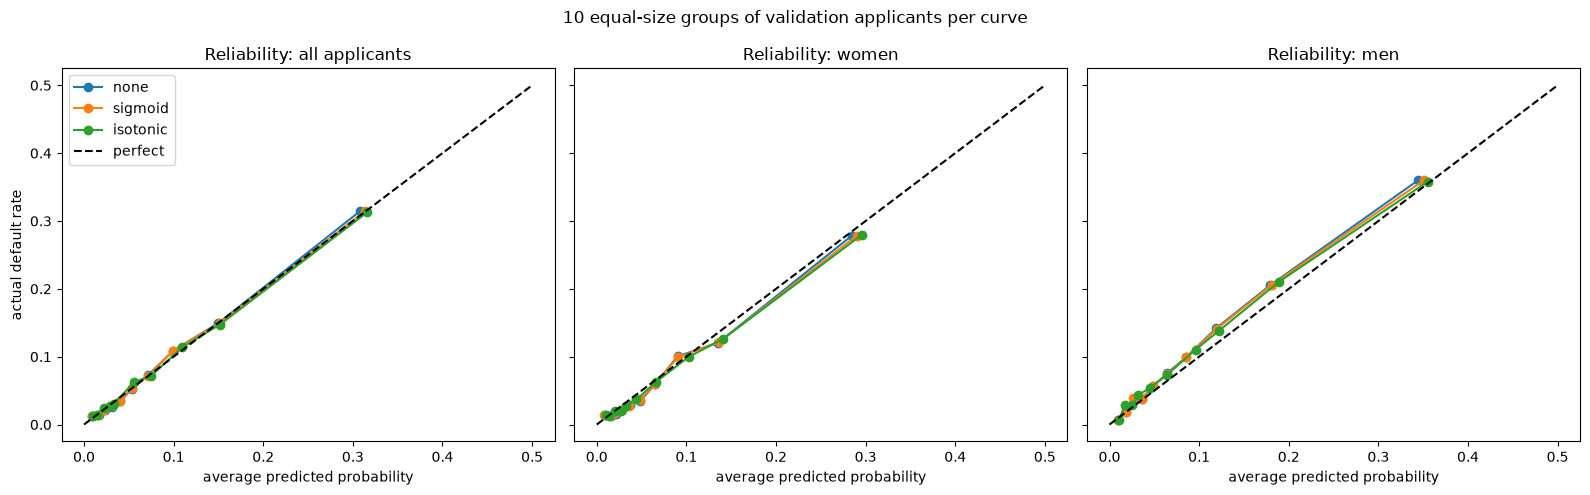

In [3]:
# keep a calibrator only if it is clearly better (its Brier CI is below 0); otherwise keep the raw model
chosen = best if high < 0 else "none"
p_cal = probs[chosen]
print("chosen:", chosen)
facts["chosen_calibration"] = chosen

by_gender = []
for g in ("F", "M"):
    s = gender == g
    rate, half = y[s].mean(), 1.96 * np.sqrt(y[s].mean() * (1 - y[s].mean()) / s.sum())
    by_gender.append({"gender": g, "applicants": int(s.sum()), "actual default rate": rate,
                      "avg p (raw)": p_raw[s].mean(), "avg p (chosen)": p_cal[s].mean(),
                      "actual - avg p": rate - p_cal[s].mean(),
                      "95% CI of actual": f"{rate - half:.4f} to {rate + half:.4f}",
                      "ECE (raw)": expected_calibration_error(y[s], p_raw[s]),
                      "ECE (chosen)": expected_calibration_error(y[s], p_cal[s])})
by_gender = pd.DataFrame(by_gender).set_index("gender").round(4)
display(by_gender)
facts["calibration_by_gender"] = by_gender.to_dict("index")

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, (title, s) in zip(axes, [("all applicants", np.ones(len(y), bool)),
                                 ("women", gender == "F"), ("men", gender == "M")]):
    for name, p in probs.items():
        actual, predicted = calibration_curve(y[s], p[s], n_bins=10, strategy="quantile")
        ax.plot(predicted, actual, marker="o", label=name)
    ax.plot([0, 0.5], [0, 0.5], "k--", label="perfect")
    ax.set(title=f"Reliability: {title}", xlabel="average predicted probability")
axes[0].set_ylabel("actual default rate")
axes[0].legend()
fig.suptitle("10 equal-size groups of validation applicants per curve")
fig.tight_layout()
fig.savefig(FIG / "fig20_reliability.png", dpi=150)
plt.show()

## B. The money threshold

Approving a loan of size A earns m·A if it is repaid and loses LGD·A if it defaults, so approving
is worth it only when p < m / (m + LGD). **Assumptions:** margin m = 10% of the loan, loss given
default LGD = 50%. These are illustrative numbers, not Home Credit's real economics, which is why
part C varies them.

**Check:** if the probabilities are calibrated, the threshold that made the most money on the
real outcomes should be close to the formula's break-even point.

,threshold,approval rate,defaulters declined,good customers declined,profit (millions)
rule,,,,,
break-even (formula),0.1667,0.8744,0.4452,0.0975,1144.1754
best on validation,0.1850,0.8941,0.4025,0.0798,1147.3925
approve everyone,1.0000,1.0000,0.0000,0.0000,1011.4552


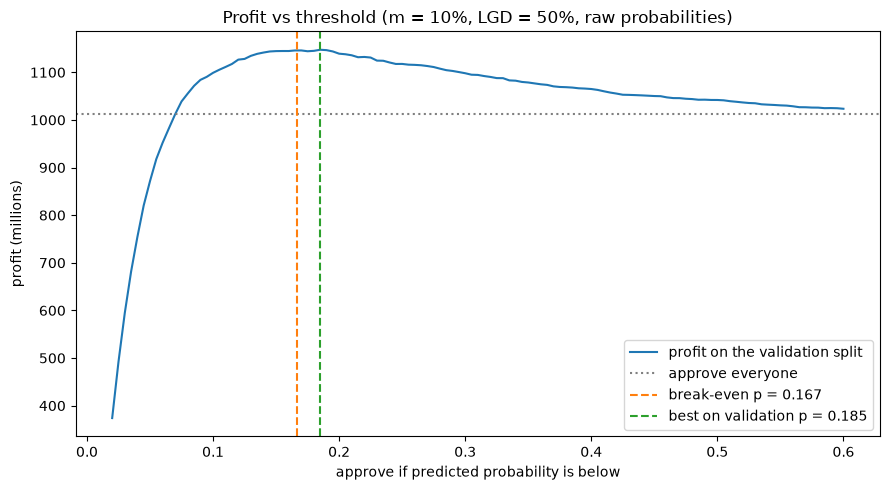

In [4]:
MARGIN, LGD = 0.10, 0.50
threshold = break_even_threshold(MARGIN, LGD)

grid = np.round(np.arange(0.02, 0.60001, 0.005), 3)
profit = np.array([realised_profit(y, amount, p_cal < t, MARGIN, LGD) for t in grid])
best_t = float(grid[profit.argmax()])
everyone = realised_profit(y, amount, np.ones(len(y), bool), MARGIN, LGD)

rows = []
for label, t in [("break-even (formula)", threshold), ("best on validation", best_t),
                 ("approve everyone", 1.0)]:
    d = evaluate_at_threshold(y, p_cal, t)
    rows.append({"rule": label, "threshold": round(t, 4), "approval rate": d["approval_rate"],
                 "defaulters declined": d["recall"],
                 "good customers declined": d["fp"] / (d["fp"] + d["tn"]),
                 "profit (millions)": realised_profit(y, amount, p_cal < t, MARGIN, LGD) / 1e6})
thresholds = pd.DataFrame(rows).set_index("rule").round(4)
display(thresholds)
thresholds.to_csv(REPORTS / "results_step10_thresholds.csv")
facts["thresholds"] = thresholds.to_dict("index")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grid, profit / 1e6, label="profit on the validation split")
ax.axhline(everyone / 1e6, color="grey", linestyle=":", label="approve everyone")
ax.axvline(threshold, color="C1", linestyle="--", label=f"break-even p = {threshold:.3f}")
ax.axvline(best_t, color="C2", linestyle="--", label=f"best on validation p = {best_t:.3f}")
ax.set(xlabel="approve if predicted probability is below", ylabel="profit (millions)",
       title=f"Profit vs threshold (m = {MARGIN:.0%}, LGD = {LGD:.0%}, "
             f"{'raw' if chosen == 'none' else chosen} probabilities)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig21_profit_vs_threshold.png", dpi=150)
plt.show()

## C. Sensitivity to the assumptions

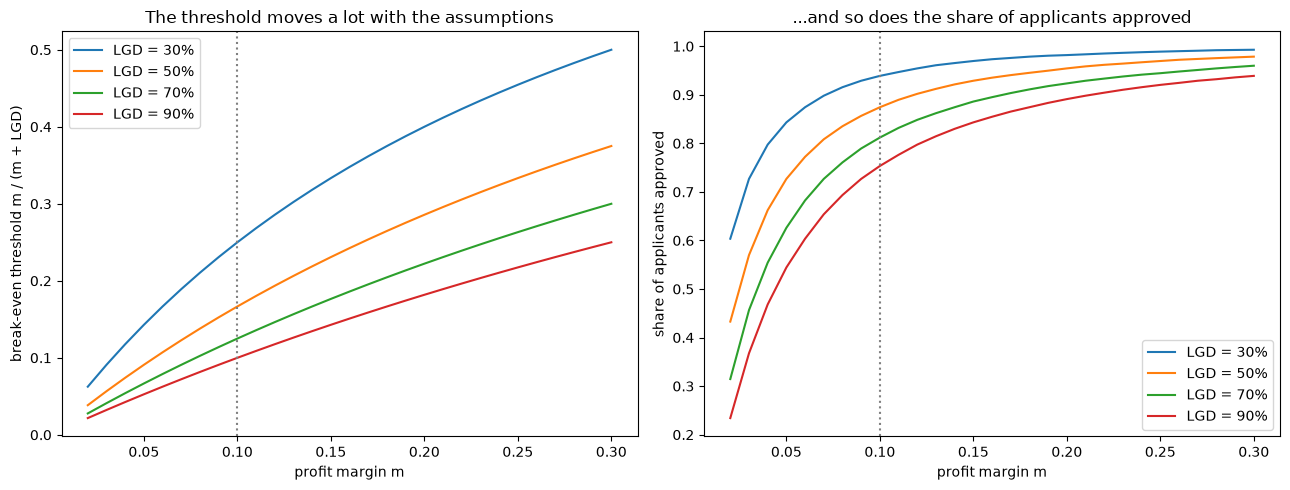

approval rate at the corners: {'m=5%, LGD=30%': 0.8432, 'm=5%, LGD=90%': 0.5444, 'm=30%, LGD=30%': 0.9928, 'm=30%, LGD=90%': 0.939}


In [5]:
margins = np.linspace(0.02, 0.30, 29)
lgds = [0.3, 0.5, 0.7, 0.9]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for lgd in lgds:
    ts = np.array([break_even_threshold(m, lgd) for m in margins])
    ax1.plot(margins, ts, label=f"LGD = {lgd:.0%}")
    ax2.plot(margins, [(p_cal < t).mean() for t in ts], label=f"LGD = {lgd:.0%}")
ax1.set(xlabel="profit margin m", ylabel="break-even threshold m / (m + LGD)",
        title="The threshold moves a lot with the assumptions")
ax2.set(xlabel="profit margin m", ylabel="share of applicants approved",
        title="...and so does the share of applicants approved")
for ax in (ax1, ax2):
    ax.axvline(MARGIN, color="grey", linestyle=":")
    ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig22_threshold_sensitivity.png", dpi=150)
plt.show()

corners = {f"m={m:.0%}, LGD={l:.0%}": round(float((p_cal < break_even_threshold(m, l)).mean()), 4)
           for m in (0.05, 0.30) for l in (0.3, 0.9)}
print("approval rate at the corners:", corners)
facts["approval_rate_corners"] = corners

## Save for Steps 11 and 16

In [6]:
if chosen == "none":
    final = model
else:
    final = CalibratedClassifierCV(FrozenEstimator(model), method=chosen).fit(X, y)
joblib.dump(final, MODEL_DIR / "calibrated_final.joblib")
decision = {
    "step": 10,
    "calibration": chosen,
    "fitted_on": f"validation split, {len(y):,} rows",
    "margin": MARGIN,
    "lgd": LGD,
    "threshold": round(threshold, 6),
    "validation": thresholds.loc["break-even (formula)"].to_dict(),
}
(MODEL_DIR / "decision.json").write_text(json.dumps(decision, indent=2))
check = joblib.load(MODEL_DIR / "calibrated_final.joblib").predict_proba(X.head(5))[:, 1]
print("saved; first 5 calibrated probabilities:", np.round(check, 4))

saved; first 5 calibrated probabilities: [0.0233 0.0707 0.1867 0.012  0.0214]


In [7]:
for key, value in facts.items():
    print(f"{key}: {value}")

calibration: {'none': {'Brier': 0.06529, 'ECE': 0.00236, 'avg predicted p': 0.08028}, 'sigmoid': {'Brier': 0.0653, 'ECE': 0.0017, 'avg predicted p': 0.08071}, 'isotonic': {'Brier': 0.06534, 'ECE': 0.00121, 'avg predicted p': 0.08075}}
best_brier: ('sigmoid', -1.6e-05, 2.7e-05)
chosen_calibration: none
calibration_by_gender: {'F': {'applicants': 20314, 'actual default rate': 0.0687, 'avg p (raw)': 0.0736, 'avg p (chosen)': 0.0736, 'actual - avg p': -0.0048, '95% CI of actual': '0.0652 to 0.0722', 'ECE (raw)': 0.0052, 'ECE (chosen)': 0.0052}, 'M': {'applicants': 10437, 'actual default rate': 0.1041, 'avg p (raw)': 0.0934, 'avg p (chosen)': 0.0934, 'actual - avg p': 0.0107, '95% CI of actual': '0.0982 to 0.1099', 'ECE (raw)': 0.0115, 'ECE (chosen)': 0.0115}}
thresholds: {'break-even (formula)': {'threshold': 0.1667, 'approval rate': 0.8744, 'defaulters declined': 0.4452, 'good customers declined': 0.0975, 'profit (millions)': 1144.1754}, 'best on validation': {'threshold': 0.185, 'approva

## Findings

- **The model was already calibrated:** on the validation split its average probability is 8.03% vs an actual default rate of 8.07% (ECE 0.0024, Brier 0.06529). Platt scaling changes the Brier score by +0.000005 (95% CI −0.000016 to +0.000027), so no gain; isotonic is slightly worse (Brier 0.06534) and costs ranking, ROC-AUC 0.7931 → 0.7908, because its step function creates ties. **Decision: keep the raw probabilities** (`calibration = "none"`). This matches Step 7: boosting trained on log loss, with no resampling or class weights, already gives honest probabilities.
- **Calibrated overall, but not within gender:** the model never sees gender, and it over-predicts for women (7.36% predicted vs 6.87% actual, 95% CI 6.52% to 7.22%) and under-predicts for men (9.34% vs 10.41%, 95% CI 9.82% to 10.99%). Both gaps are real (outside the CIs). A global calibrator cannot fix this because it does not see gender either; fixing it would need gender at decision time. That is exactly the trade-off of Step 13 (with different base rates, calibration within groups and equal error rates cannot both hold), so it is reported here and handled there.
- **Money threshold (m = 10%, LGD = 50%):** approve if p < 0.1667. That approves 87.4% of applicants, declines 44.5% of the defaulters and 9.8% of the good customers, and makes 1,144M vs 1,011M for approving everyone (+13.1%).
- **The formula agrees with the data:** the threshold that made the most money on the validation split is 0.185 (1,147M, only 0.3% more), and the profit curve is flat between about 0.15 and 0.20. Because the probabilities are calibrated, the break-even formula is already close to the best possible threshold, with no tuning on outcomes.
- **The assumptions matter more than the calibration method:** across m = 2–30% and LGD = 30–90% the threshold moves from 0.02 to 0.50, and the approval rate from 54% (m = 5%, LGD = 90%) to 99% (m = 30%, LGD = 30%). The report must state m and LGD as assumptions; Step 11's refer zone handles the applicants the model is unsure about.
- **Saved:** `models/calibrated_final.joblib` (here the raw model, since no calibrator helped) and `models/decision.json` (method, m, LGD, threshold, validation results). Steps 11 and 16 load these.